🚀 TASK 2 STARTED

First 5 Rows:

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Shape of dataset:
(150, 5)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
spec

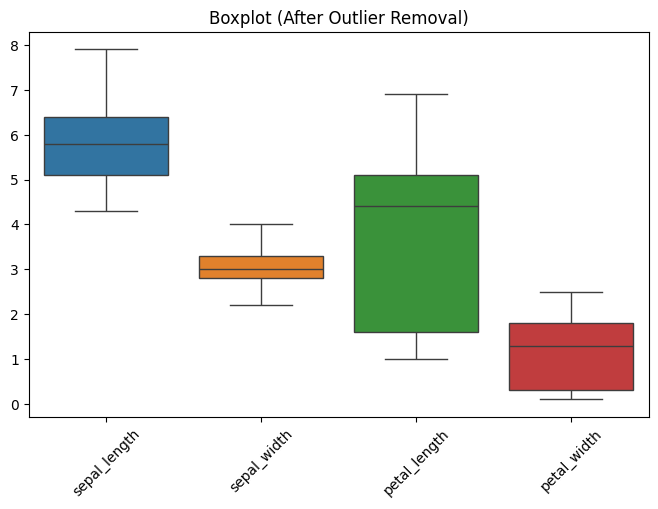

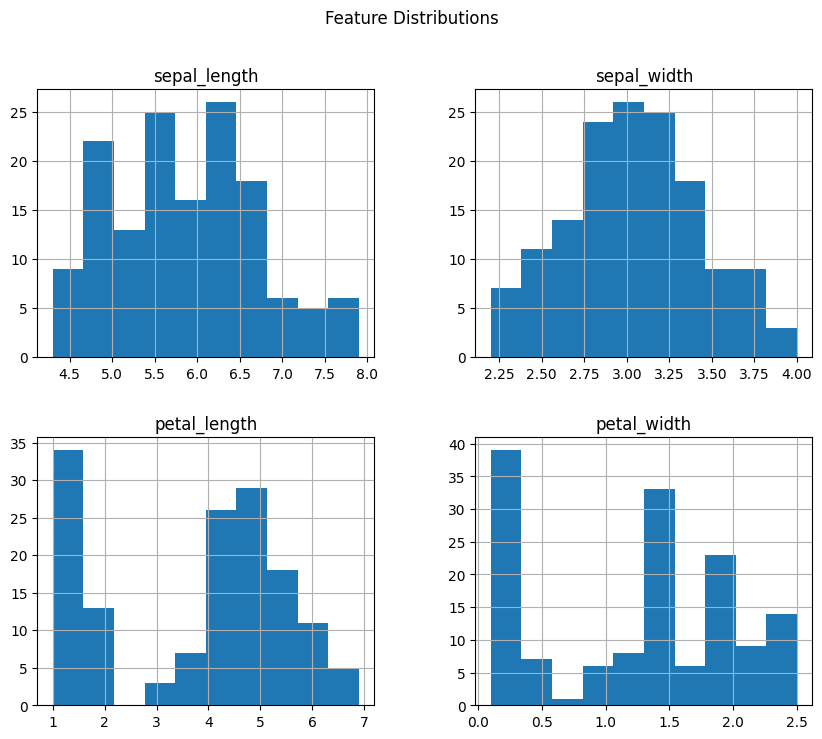

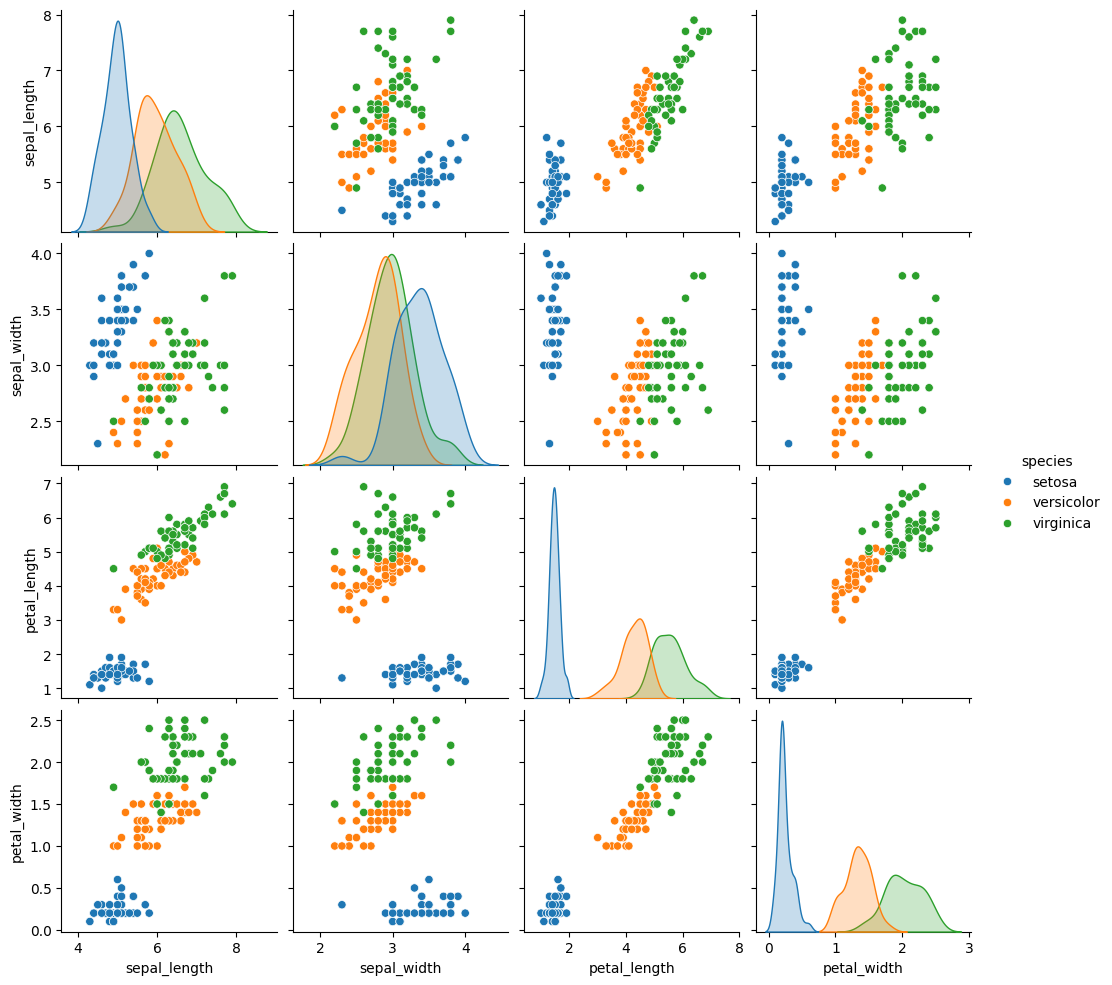


✅ TASK 2 COMPLETED SUCCESSFULLY


In [15]:
# TASK 2: DATA CLEANING & PREPROCESSING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline

print("🚀 TASK 2 STARTED\n")

# LOAD DATASET

df = pd.read_csv("../datasets/iris.csv")

print("First 5 Rows:\n")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics (Numeric Columns):")
print(df.describe())


# OUTLIER DETECTION (IQR METHOD)

numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

filtered_df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
                   (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nOriginal rows:", df.shape[0])
print("Rows after removing outliers:", filtered_df.shape[0])

# FEATURE SCALING

scaler = StandardScaler()
scaled = scaler.fit_transform(filtered_df.select_dtypes(include=np.number))

scaled_df = pd.DataFrame(scaled, 
                         columns=filtered_df.select_dtypes(include=np.number).columns)

print("\nScaled Data Preview:\n")
print(scaled_df.head())

# VISUALIZATIONS 

# 1️⃣ BOXPLOT
plt.figure(figsize=(8,5))
sns.boxplot(data=filtered_df.select_dtypes(include=np.number))
plt.title("Boxplot (After Outlier Removal)")
plt.xticks(rotation=45)
plt.show()

# 2️⃣ HISTOGRAMS
filtered_df.select_dtypes(include=np.number).hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

# 3️⃣ PAIRPLOT
sns.pairplot(filtered_df, hue="species")
plt.show()

print("\n✅ TASK 2 COMPLETED SUCCESSFULLY")
